In [1]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models
from loss_functions.loss_nll import custom_loss

import OptimizedDataGenerator_v2 as DG
#from loss_functions.loss_hybrid3 import * # this one matters
#from loss_functions.loss_nll import *
from loss_functions.Slim_SSE import *
#from models.models import *
from models.Slim1D_model_Compression import *
import utils
pi = 3.14159265359

maxval=1e9
minval=1e-9

2025-09-24 22:03:15.747499: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-24 22:03:15.747570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-24 22:03:15.748696: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-24 22:03:15.756080: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 22:03:32.845503: W tensorflow/compiler/tf2

In [2]:

fingerprint = '93677f46'
# c9ce48b7
TimeSlice = 20
input_shape = (16, 16, TimeSlice)
model = CreateSlim1DModel(
    input_shape=input_shape,
    
    # ========== MODEL SIZE PARAMETERS ==========
    conv_filters=5,           # Conv1D filters (5 original)
    conv_kernel_size=3,       # Conv1D kernel size (3 original)
    dense1_units=16,          # First dense layer size (16 original)
    dense2_units=16,          # Second dense layer size (16 original)
    output_units=3,           # Output size (keep at 3 for x,y,β)
    
    # ========== QUANTIZATION PARAMETERS ==========
    use_quantization=False,   # True/False to enable QKeras
    conv_weight_bits=4,       # Conv1D weight precision (4 like baseline)
    conv_activation_bits=4,   # Conv1D activation precision (4 like baseline)
    dense_weight_bits=8,      # Dense weight precision (8 like baseline)
    dense_activation_bits=8,  # Dense activation precision (8 like baseline)
    
    # ========== PRUNING PARAMETERS ==========
    use_pruning=False,        # True/False to enable pruning
    pruning_fraction=0.3,     # 0.2=20%, 0.5=50%, 0.8=80% weights removed
    pruning_schedule='constant'  # 'constant' or 'polynomial_decay'
)
'''
model = CreateSlim1DModel(
    input_shape=(16, 16, 2))
'''
base_dir = f'./trained_models/model-{fingerprint}-checkpoints/'
checkpoint_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.hdf5')]
latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
training_cp_path = os.path.join(base_dir, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

print(f"Loading model from {latest_checkpoint}")
model.load_weights(latest_checkpoint)


Loading model from ./trained_models/model-93677f46-checkpoints/weights.990-t40.91-v39.95.hdf5


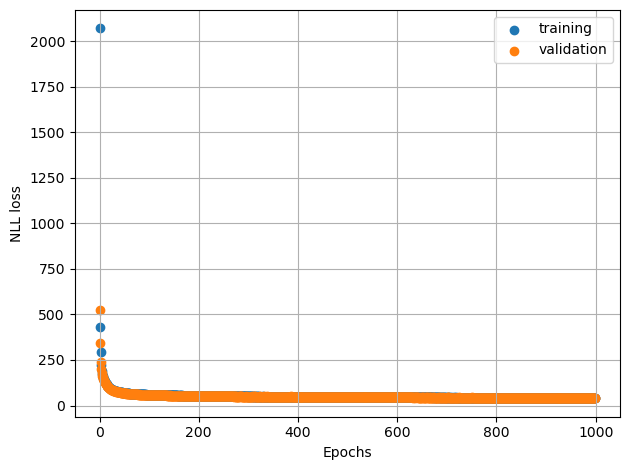

In [3]:
plt.scatter(training_history['epoch'], training_history['loss'])
plt.scatter(training_history['epoch'], training_history['val_loss'])
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

#plt.savefig(os.path.join(base_dir,'training_hist.png'))
plt.show()

In [4]:
print(training_history.to_string())


     epoch  cotBeta_mae_metric         loss  slim_rmse_metric  val_cotBeta_mae_metric    val_loss  val_slim_rmse_metric  val_x_mae_metric  val_y_mae_metric  x_mae_metric  y_mae_metric
0        0            0.207795  2068.866455          0.348819                0.098185  525.937988              0.190574          0.143344          0.180035      0.298298      0.339550
1        1            0.080786   432.343048          0.168846                0.068685  343.477203              0.153787          0.122261          0.134855      0.129952      0.154575
2        2            0.063186   296.188904          0.139479                0.059876  241.026794              0.128475          0.106401          0.101312      0.113856      0.117231
3        3            0.058745   221.881378          0.120529                0.057344  197.729294              0.116083          0.094453          0.088590      0.099614      0.093675
4        4            0.055876   190.754654          0.111593                0.0

In [5]:
batch_size = 5000
test_batch_size = 5000
test_file_size = 20
data_directory_path = "/depot/cms/users/kuang14/Smart_Pixel/dataset_s_series/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_parquets/contained/test"
tfrecords_dir_validation = "/depot/cms/users/kuang14/Smart_Pixel/tf_records/16x16test_3"
test_generator = DG.OptimizedDataGenerator(
    # Base directory where your parquet files are located
    dataset_base_dir = data_directory_path,
    is_directory_recursive = False,
    batch_size = test_batch_size,
    file_count = test_file_size,
    to_standardize = True,
    include_y_local = False,
    # Labels you want to extract
    labels_list = ['x-midplane', 'y-midplane', 'cotBeta'], 
    # Input shape for the model (time slices, height, width)
    input_shape = (TimeSlice, 16, 16),
    transpose = (0, 2, 3, 1),
    shuffle = False,
    files_from_end = False,
    
    # New parameters specific to this generator
    tfrecords_dir = tfrecords_dir_validation,
    use_time_stamps = -1,  # [0, 19]Specific time stamps to use
    quantize = False,  # Whether to use quantization during loading
    max_workers = 2  # For parallel processing
)

Processing Files...: 100%|██████████| 20/20 [00:27<00:00,  1.35s/it]


Directory /depot/cms/users/kuang14/Smart_Pixel/tf_records/16x16test_3 is removed...


Saving batches as TFRecords: 100%|██████████| 22/22 [01:19<00:00,  3.60s/it]


Metadata saved successfully ast /depot/cms/users/kuang14/Smart_Pixel/tf_records/16x16test_3/metadata.json
Loading metadata from /depot/cms/users/kuang14/Smart_Pixel/tf_records/16x16test_3/metadata.json


In [6]:
model.summary()

Model: "smrtpxl_slim_tunable"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_pxls/ (InputLayer)    [(None, 16, 16, 20)]         0         []                            
                                                                                                  
 avg_pooling_2d_proj_x (Ave  (None, 16, 1, 20)            0         ['input_pxls/[0][0]']         
 ragePooling2D)                                                                                   
                                                                                                  
 avg_pooling_2d_proj_y (Ave  (None, 1, 16, 20)            0         ['input_pxls/[0][0]']         
 ragePooling2D)                                                                                   
                                                                               

In [7]:
# predicts test data
p_test = model.predict(test_generator)

2025-09-24 22:08:29.351659: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-09-24 22:08:29.589745: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


22/22 [==============================] - 6s 159ms/step


In [8]:
complete_truth = None
for _, y in tqdm(test_generator):
        if complete_truth is None:
            complete_truth = y
        else:
            complete_truth = np.concatenate((complete_truth, y), axis=0)

100%|██████████| 22/22 [00:03<00:00,  6.52it/s]


In [9]:
df = pd.DataFrame(p_test, columns=['x', 'y', 'cotB'])

# Store true values (only 3 for slim model)
df['xtrue'] = complete_truth[:,0]
df['ytrue'] = complete_truth[:,1] 
df['cotBtrue'] = complete_truth[:,2]  # Note: cotB is now at index 2

# Calculate residuals
df['x_residual'] = df['xtrue'] - df['x']
df['y_residual'] = df['ytrue'] - df['y']
df['cotB_residual'] = df['cotBtrue'] - df['cotB']

# ADD THESE LINES for the metric calculation cells:
residuals = df['x_residual']    # For X metrics
residualsy = df['y_residual']   # For Y metrics  
residualsB = df['cotB_residual'] # For CotB metrics

# Save results
df.to_csv("test_slim_model.csv", header=True, index=False)

### Define Scaling factors first

In [10]:
Scaling_factors = test_generator.labels_scale
print(Scaling_factors)

[99.11786584 24.80232129  1.91059443]


In [11]:
SCALE_FACTOR_X = Scaling_factors[0]      # Scaling factor for x position [μm]
SCALE_FACTOR_Y = Scaling_factors[1]  # Scaling factor for y position [μm]
#SCALE_FACTOR_COTA = 8.95462059   # Scaling factor for cotangent alpha
SCALE_FACTOR_COTB = Scaling_factors[2] # Scaling factor for cotangent beta
#array([99.1550028 , 24.77847354,  8.95462059,  4.12538643])
print(SCALE_FACTOR_X, SCALE_FACTOR_Y, SCALE_FACTOR_COTB)

99.11786583963806 24.802321286614486 1.9105944285582266


# residuals (mean, stdv)

In [12]:
def shortest_interval_68(data, center_type='mean'):
    """
    Compute the shortest interval that contains 68% of the data.
    """
    data = np.sort(data)
    n = len(data)
    ci_size = int(np.floor(0.68 * n))
    min_width = float("inf")
    min_i = 0

    for i in range(n - ci_size):
        width = data[i + ci_size] - data[i]
        if width < min_width:
            min_width = width
            min_i = i

    low = data[min_i]
    high = data[min_i + ci_size]

    if center_type == 'mean':
        center = np.mean(data)
    else:
        center = np.median(data)

    return {
        "center": center,
        "error_low": center - low,
        "error_high": high - center,
        "center_type": center_type
    }

def cotbeta_to_beta_degrees_correct(cotbeta_values):
    """Convert cotBeta to Beta in degrees, ensuring [0, 180] range"""
    beta_rad = np.arctan(1.0 / cotbeta_values)
    beta_deg = np.degrees(beta_rad)
    
    # Ensure angles are in [0, 180] range
    beta_deg = np.where(beta_deg < 0, beta_deg + 180, beta_deg)
    
    return beta_deg

In [13]:
# Convert cotB to beta in degrees
df['beta_true_deg'] = cotbeta_to_beta_degrees_correct(df['cotBtrue'])
df['beta_pred_deg'] = cotbeta_to_beta_degrees_correct(df['cotB'])
df['beta_deg_residual'] = df['beta_true_deg'] - df['beta_pred_deg']

In [14]:
# X residuals
x_result = shortest_interval_68(df['x_residual'], center_type='mean')
print(f"X: mean={x_result['center']*SCALE_FACTOR_X:.4f}, -error={x_result['error_low']*SCALE_FACTOR_X:.4f}, +error={x_result['error_high']*SCALE_FACTOR_X:.4f}")

# Y residuals  
y_result = shortest_interval_68(df['y_residual'], center_type='mean')
print(f"Y: mean={y_result['center']*SCALE_FACTOR_Y:.4f}, -error={y_result['error_low']*SCALE_FACTOR_Y:.4f}, +error={y_result['error_high']*SCALE_FACTOR_Y:.4f}")

# Beta residuals (in degrees, no scale factor needed)
beta_result = shortest_interval_68(df['beta_deg_residual'], center_type='mean')
print(f"Beta: mean={beta_result['center']:.4f}°, -error={beta_result['error_low']:.4f}°, +error={beta_result['error_high']:.4f}°")

X: mean=-0.2152, -error=4.4124, +error=4.7655
Y: mean=0.0850, -error=0.9836, +error=1.0345
Beta: mean=0.0034°, -error=0.8585°, +error=0.8265°


In [15]:
(np.mean(residuals)*SCALE_FACTOR_X, np.std(residuals)*SCALE_FACTOR_X)

(-0.21515204721305506, 5.331768160209284)

In [16]:
(np.mean(residualsy)*SCALE_FACTOR_Y, np.std(residualsy)*SCALE_FACTOR_Y)

(0.08499273358336072, 1.4583042553971832)

In [17]:
(np.mean(residualsB)*SCALE_FACTOR_COTB, np.std(residualsB)*SCALE_FACTOR_COTB)

(-0.00033625989557522514, 0.0489280561851807)

In [18]:
def residual_plot_slim(ax, thisdf, var1, var2, name, scaling=1.0):
    """
    Residual plot for slim model (no uncertainty estimates)
    Creates binned residual plot with statistical uncertainty bands
    """
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    # Create binned scatter plot
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), 
                   fit_reg=None, marker='.', ax=ax, scatter_kws={'s': 20})
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    # Calculate binned statistics for uncertainty bands
    bin_centers = []
    means = []
    stds = []
    
    for i in range(nbins):
        bin_mask = (var1_scaled >= xmin + i*step) & (var1_scaled < xmin + (i+1)*step)
        if np.sum(bin_mask) > 0:  # Only if there are points in this bin
            bin_centers.append(xmin + (i+0.5)*step)
            bin_residuals = residual_scaled[bin_mask]
            means.append(np.mean(bin_residuals))
            stds.append(np.std(bin_residuals))
    
    bin_centers = np.array(bin_centers)
    means = np.array(means)
    stds = np.array(stds)
    
    # Create uncertainty bands (±1 standard deviation)
    upbar = means + stds
    downbar = means - stds
    
    # Fill between for uncertainty band
    ax.fill_between(bin_centers, upbar, downbar, alpha=0.3, color='lightblue')
    
    return ax

def residual_plot_deg_slim(ax, thisdf, var1, var2, name, scaling=1.0):
    """
    Residual plot for cotangent values converted to degrees
    """
    # If not a cotangent variable, use regular residual plot
    if 'cot' not in var1:
        return residual_plot_slim(ax, thisdf, var1, var2, name, scaling=scaling)

    # Convert cotangent to degrees
    def inverse_cot(cota):
        a = np.arctan(1.0/cota)
        a = np.where(a < 0, a + np.pi, a)  # Using np.where for array operations
        return a    

    # Create temporary copies for degree conversion
    thisdf_copy = thisdf.copy()
    
    # Convert predictions to degrees
    thisdf_copy['angle'] = inverse_cot(thisdf_copy[var2].values * scaling) * 180 / np.pi
    
    # Convert true values to degrees  
    thisdf_copy['angletrue'] = inverse_cot(thisdf_copy[var1].values * scaling) * 180 / np.pi
    
    # Calculate angular residuals
    angular_residuals = thisdf_copy['angletrue'] - thisdf_copy['angle']
    
    var1_deg = thisdf_copy['angletrue']
    
    nbins = 15
    xmin = np.min(var1_deg)
    xmax = np.max(var1_deg)
    step = (xmax - xmin) / nbins
    
    # Create binned scatter plot
    sns.regplot(x=var1_deg, y=angular_residuals, x_bins=np.linspace(xmin, xmax, nbins), 
               fit_reg=None, marker='.', ax=ax, scatter_kws={'s': 20})
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    # Calculate binned statistics
    bin_centers = []
    means = []
    stds = []
    
    for i in range(nbins):
        bin_mask = (var1_deg >= xmin + i*step) & (var1_deg < xmin + (i+1)*step)
        if np.sum(bin_mask) > 0:
            bin_centers.append(xmin + (i+0.5)*step)
            bin_residuals = angular_residuals[bin_mask]
            means.append(np.mean(bin_residuals))
            stds.append(np.std(bin_residuals))
    
    bin_centers = np.array(bin_centers)
    means = np.array(means)
    stds = np.array(stds)
    
    # Create uncertainty bands
    upbar = means + stds
    downbar = means - stds
    
    ax.fill_between(bin_centers, upbar, downbar, alpha=0.3, color='lightblue')
    
    return ax


In [19]:
def create_slim_summary_plot_horizontal(df, base_dir):
   """
   Create horizontal summary residual plot for Slim model (1x3 layout)
   """
   fig, axes = plt.subplots(1, 3, figsize=(18, 6))
   fig.tight_layout(pad=4.0)
   
   # X residuals
   residual_plot_slim(axes[0], df, 'xtrue', 'x', r'$x$ [μm]', scaling=SCALE_FACTOR_X)
   axes[0].axhline(0, color='gray', linestyle=':', alpha=0.7)
   axes[0].axvline(-25, color='gray', linestyle=':', alpha=0.7)
   axes[0].axvline(25, color='gray', linestyle=':', alpha=0.7)
   axes[0].set_ylim([-10, 10])
   
   # Y residuals
   residual_plot_slim(axes[1], df, 'ytrue', 'y', r'$y$ [μm]', scaling=SCALE_FACTOR_Y)
   axes[1].axhline(0, color='gray', linestyle=':', alpha=0.7)
   axes[1].axvline(-6.25, color='gray', linestyle=':', alpha=0.7)
   axes[1].axvline(6.25, color='gray', linestyle=':', alpha=0.7)
   axes[1].set_ylim([-10, 10])
   
   # CotB residuals (converted to degrees)
   residual_plot_deg_slim(axes[2], df, 'cotBtrue', 'cotB', r'$β$ [deg]', scaling=SCALE_FACTOR_COTB)
   axes[2].axhline(0, color='gray', linestyle=':', alpha=0.7)
   axes[2].axvline(90, color='gray', linestyle=':', alpha=0.7)
   axes[2].set_ylim([-10, 10])
   
   # Save figure
   save_fig_path = os.path.join(base_dir, 'slim_residual_summary_horizontal.png')
   plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
   plt.show()
   
   return fig

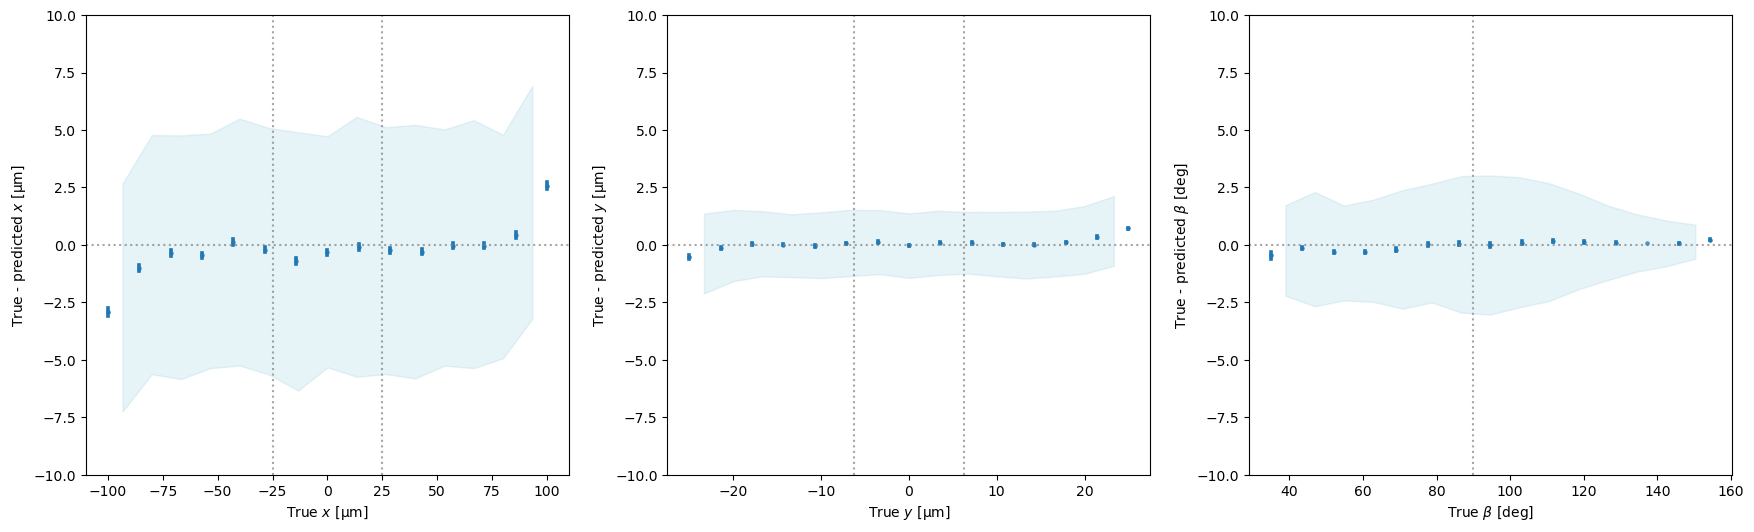

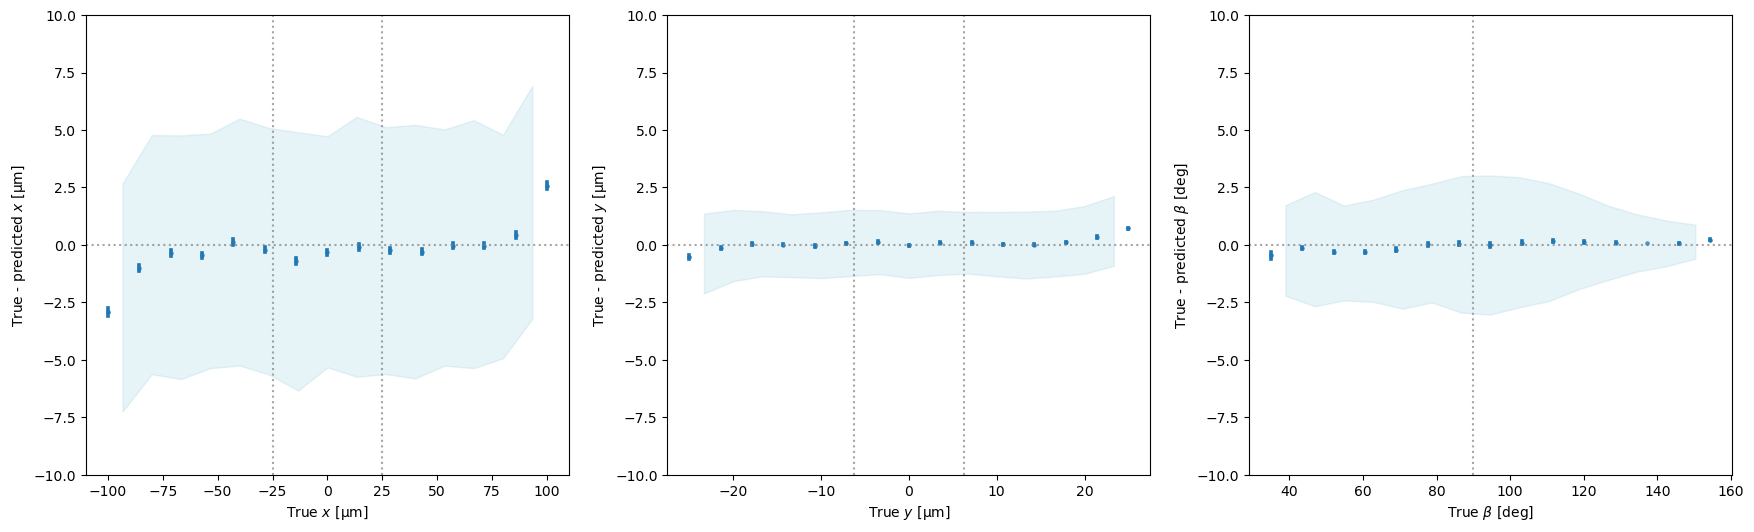

In [20]:
create_slim_summary_plot_horizontal(df, base_dir)

In [21]:
def create_slim_summary_plot_horizontal(df, base_dir):
   """
   Create horizontal summary residual plot for Slim model (1x3 layout)
   """
   fig, axes = plt.subplots(1, 3, figsize=(18, 6))
   fig.tight_layout(pad=4.0)
   
   # X residuals
   residual_plot_slim(axes[0], df, 'xtrue', 'x', r'$x$ [μm]', scaling=SCALE_FACTOR_X)
   axes[0].axhline(0, color='gray', linestyle=':', alpha=0.7)
   axes[0].axvline(-25, color='gray', linestyle=':', alpha=0.7)
   axes[0].axvline(25, color='gray', linestyle=':', alpha=0.7)
   axes[0].set_ylim([-10, 10])
   
   # Y residuals
   residual_plot_slim(axes[1], df, 'ytrue', 'y', r'$y$ [μm]', scaling=SCALE_FACTOR_Y)
   axes[1].axhline(0, color='gray', linestyle=':', alpha=0.7)
   axes[1].axvline(-6.25, color='gray', linestyle=':', alpha=0.7)
   axes[1].axvline(6.25, color='gray', linestyle=':', alpha=0.7)
   axes[1].set_ylim([-10, 10])
   
   # CotB residuals (converted to degrees)
   residual_plot_deg_slim(axes[2], df, 'cotBtrue', 'cotB', r'$β$ [deg]', scaling=SCALE_FACTOR_COTB)
   axes[2].axhline(0, color='gray', linestyle=':', alpha=0.7)
   axes[2].axvline(90, color='gray', linestyle=':', alpha=0.7)
   axes[2].set_ylim([-10, 10])
   
   # Save figure
   save_fig_path = os.path.join(base_dir, 'slim_residual_summary_horizontal.png')
   plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
   plt.show()
   
   return fig

In [22]:
print(os.getcwd())

/depot/cms/private/users/kuang14/Smart_Pixel/Full_n_slim


In [23]:
df.to_parquet('/depot/cms/private/users/kuang14/Smart_Pixel/Full_n_slim/Model_performance/Slim_Models/Slim_Model_20t_full_precision_8869b160.parquet')